# Imports

In [79]:
import collections
import numpy as np
import pandas as pd
import glob
import os
import random

import cv2
import tensorflow as tf
import tfimm
import timm
from builtins import range, input
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model

import torch
import torch_geometric
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
import torch.nn.functional as F

In [80]:
## Hyperparameters

# PVTAD models
vis_epochs = 20
vis_batch_size = 32

# GNN models
gnn_epochs = 50 # Graph data may require fewer epochs to converge
gnn_batch_size = 64 # Graph data is smaller so we can use a larger batch size for training
hidden_channels = 32
dropout = 0.5
weight_decay = 0.00005
k_neighbors = 10
random_state = random.randint(0, 10000)
print(f"Random state: {random_state}")
random_state = 2227
heads = 4

results_summary = []

Random state: 4986


# Data Loading and FC Matrix Computation

In [81]:
## Compute Pearson Correlation Matrix

def compute_fc_matrix(filepath):
    # Each .1D file: rows = timepoints, columns = ROIs
    timeseries = np.loadtxt(filepath)  # shape: (T, n_rois)
    fc_matrix = np.corrcoef(timeseries.T)  # transpose so corrcoef treats ROIs as variables
    return fc_matrix

# Example: process every downloaded file
filepaths = glob.glob('./data/abide_aal_data/Outputs/cpac/filt_global/rois_cc200/*.1D')
fc_matrices = {}

for fp in filepaths:
    file_id = os.path.basename(fp).replace('_rois_cc200.1D', '')
    fc_matrices[file_id] = compute_fc_matrix(fp)

print(f"Processed {len(fc_matrices)} subjects")
print(f"Matrix shape: {next(iter(fc_matrices.values())).shape}")  # should be (200, 200) for CC200

c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Processed 884 subjects
Matrix shape: (200, 200)


In [82]:
## Remove NaN subjects from the dictionary of matrices

fc_matrices_clean = {fid: mat for fid, mat in fc_matrices.items() if not np.isnan(mat).any()}
print(f"Kept {len(fc_matrices_clean)} of {len(fc_matrices)} subjects; {len(fc_matrices) - len(fc_matrices_clean)} subjects have NaNs")

Kept 849 of 884 subjects; 35 subjects have NaNs


# Phenotypic Label Merge

In [83]:
## Merge subject data with phenotypic labels

pheno = pd.read_csv('./data/Phenotypic_V1_0b_preprocessed1.csv')

# Build labels lookup
labels = pheno[['FILE_ID', 'DX_GROUP', 'SEX', 'AGE_AT_SCAN', 'func_mean_fd', 'SITE_ID']].copy()
labels = labels[labels['FILE_ID'] != 'no_filename']

# Merge with your clean matrices
matched_data = []
for file_id, matrix in fc_matrices_clean.items():
    row = labels[labels['FILE_ID'] == file_id]
    if not row.empty:
        dx = row['DX_GROUP'].values[0]
        sex = row['SEX'].values[0] # 1=Male, 2=Female in ABIDE
        age = row['AGE_AT_SCAN'].values[0]
        mean_fd = row['func_mean_fd'].values[0]
        site = row['SITE_ID'].values[0]
        matched_data.append((file_id, matrix, dx, sex, age, mean_fd, site))

print(f"Matched {len(matched_data)} of {len(fc_matrices_clean)} subjects to labels")
print(matched_data)

Matched 849 of 849 subjects to labels
[('Caltech_0051459', array([[ 1.        , -0.1773661 , -0.00602314, ..., -0.28906846,
        -0.34674923,  0.00569531],
       [-0.1773661 ,  1.        ,  0.23651303, ...,  0.17127448,
        -0.06847432, -0.31333132],
       [-0.00602314,  0.23651303,  1.        , ..., -0.07478013,
        -0.01658607, -0.04234176],
       ...,
       [-0.28906846,  0.17127448, -0.07478013, ...,  1.        ,
         0.03017183, -0.22089793],
       [-0.34674923, -0.06847432, -0.01658607, ...,  0.03017183,
         1.        , -0.17733803],
       [ 0.00569531, -0.31333132, -0.04234176, ..., -0.22089793,
        -0.17733803,  1.        ]]), 1, 1, 22.8, 0.0413318031, 'CALTECH'), ('Caltech_0051461', array([[ 1.        , -0.23663444, -0.22839338, ...,  0.32799874,
         0.13613338,  0.0465256 ],
       [-0.23663444,  1.        ,  0.46683256, ...,  0.01660224,
        -0.07951879, -0.301523  ],
       [-0.22839338,  0.46683256,  1.        , ..., -0.00145756,
    

In [84]:
# Print diagnosis distribution; 1 = ASD, 2 = TDC
labels_only = [dx for (_, _, dx, _, _, _, _) in matched_data]
print(collections.Counter(labels_only))

Counter({2: 458, 1: 391})


# Preprocessing and Normalization

In [85]:
## Define the prediction array

# Both vision and graph models use the same y
y = np.array([dx for (_, _, dx, _, _, _, _) in matched_data])    # shape: (849,)

# Convert ABIDE coding (1=ASD, 2=TDC) to binary (1=ASD, 0=TDC)
y = (y == 1).astype(np.int32)

print(collections.Counter(y))

Counter({0: 458, 1: 391})


##### Vision models

In [86]:
# Build X array from matched_data
X_vis = np.array([mat for (_, mat, _, _, _, _, _) in matched_data])  # shape: (849, 200, 200)

# Normalize: map correlation values from [-1, 1] to [0, 1]
X_vis = (X_vis + 1) / 2

print(f"X_vis shape: {X_vis.shape}")
print(f"y shape: {y.shape}")
print(f"X_vis min: {X_vis.min():.4f}, X_vis max: {X_vis.max():.4f}")  # should be ~0.0 to ~1.0

X_vis shape: (849, 200, 200)
y shape: (849,)
X_vis min: 0.0204, X_vis max: 1.0000


##### Graph models

In [87]:
# Build a second, non-reshaped version of the FC matrices for GNNs
X_gnn = np.array([mat for (_, mat, _, _, _, _, _) in matched_data])  # shape: (849, 200, 200), raw correlations

sex_raw = np.array([sex for (_, _, _, sex, _, _, _) in matched_data], dtype=np.float32)
age_raw = np.array([age for (_, _, _, _, age, _, _) in matched_data], dtype=np.float32)
fd_raw  = np.array([fd for (_, _, _, _, _, fd, _) in matched_data], dtype=np.float32)
site_raw = np.array([site for (_, _, _, _, _, _, site) in matched_data])

# Convert sex array values from 1 and 2 to 0 and 1
sex_bin = (sex_raw == 2).astype(np.float32)  # 0 = male, 1 = female

print(collections.Counter(sex_bin))
print(f"Age range: {age_raw.min():.1f}-{age_raw.max():.1f}, mean_fd range: {fd_raw.min():.3f}-{fd_raw.max():.3f}")

Counter({0.0: 716, 1.0: 133})
Age range: 6.5-64.0, mean_fd range: 0.016-0.200


In [88]:
site_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
site_onehot = site_encoder.fit_transform(site_raw.reshape(-1, 1)).astype(np.float32)
num_sites = site_onehot.shape[1]
print(f"Encoding {num_sites} sites: {site_encoder.categories_[0]}")

Encoding 20 sites: ['CALTECH' 'CMU' 'KKI' 'LEUVEN_1' 'LEUVEN_2' 'MAX_MUN' 'NYU' 'OHSU' 'OLIN'
 'PITT' 'SBL' 'SDSU' 'STANFORD' 'TRINITY' 'UCLA_1' 'UCLA_2' 'UM_1' 'UM_2'
 'USM' 'YALE']


# Train Val Test Split

##### Vision models

In [89]:
# train (70%) vs. temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_vis, y, test_size=0.3, stratify=y, random_state=random_state
)

# val (15%) vs. test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=random_state
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train labels: {collections.Counter(y_train)}")
print(f"Val labels:   {collections.Counter(y_val)}")
print(f"Test labels:  {collections.Counter(y_test)}")

Train: 594, Val: 127, Test: 128
Train labels: Counter({0: 320, 1: 274})
Val labels:   Counter({0: 69, 1: 58})
Test labels:  Counter({0: 69, 1: 59})


##### Graph models

In [90]:
# Parallel split for the GNN's raw FC matrices — identical partition of subjects,

(X_train_gnn, X_temp_gnn, y_train_gnn, y_temp_gnn,
 sex_train, sex_temp, age_train, age_temp, fd_train, fd_temp, site_train, site_temp) = train_test_split(
    X_gnn, y, sex_bin, age_raw, fd_raw, site_onehot, test_size=0.3, stratify=y, random_state=random_state
)

(X_val_gnn, X_test_gnn, y_val_gnn, y_test_gnn,
 sex_val, sex_test, age_val, age_test, fd_val, fd_test, site_val, site_test) = train_test_split(
    X_temp_gnn, y_temp_gnn, sex_temp, age_temp, fd_temp, site_temp, test_size=0.5, stratify=y_temp_gnn, random_state=random_state
)

# standardize age and mean_fd for GNN
age_mean, age_std = age_train.mean(), age_train.std()
fd_mean, fd_std = fd_train.mean(), fd_train.std()

age_train_z = (age_train - age_mean) / age_std
age_val_z   = (age_val   - age_mean) / age_std
age_test_z  = (age_test  - age_mean) / age_std

fd_train_z = (fd_train - fd_mean) / fd_std
fd_val_z   = (fd_val   - fd_mean) / fd_std
fd_test_z  = (fd_test  - fd_mean) / fd_std

print(f"Graph train: {len(X_train_gnn)}, val: {len(X_val_gnn)}, test: {len(X_test_gnn)}")

Graph train: 594, val: 127, test: 128


# Model Definition ----------------

##### Reshape data for vision transformers

In [91]:
# Resize X arrays to match pretrained backbone expectations
X_train_model = tf.image.resize(X_train[..., np.newaxis], [224, 224]).numpy()
X_val_model   = tf.image.resize(X_val[..., np.newaxis],   [224, 224]).numpy()
X_test_model  = tf.image.resize(X_test[..., np.newaxis],  [224, 224]).numpy()

# Tile single channel to 3 channels (pretrained models expect RGB input)
X_train_model = np.repeat(X_train_model, 3, axis=-1)
X_val_model   = np.repeat(X_val_model,   3, axis=-1)
X_test_model  = np.repeat(X_test_model,  3, axis=-1)

# Input shape variable used by all three models
inp_y = Input(shape=(224, 224, 3)) # Added for ViT model

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (594, 224, 224, 3)
X_val_model shape:   (127, 224, 224, 3)
X_test_model shape:  (128, 224, 224, 3)


##### Sparsify FC matrices for GNN

In [92]:
# Sparsify FC matrix such that only the k most correlated values for each node, all other connections will be zeroed out
def sparsify_topk(fc_matrix, k=k_neighbors):
    n = fc_matrix.shape[0]
    mask = np.zeros_like(fc_matrix, dtype=bool)

    for i in range(n):
        row = fc_matrix[i].copy()
        row[i] = 0  # exclude self-loop; GCNConv adds these separately
        top_k_idx = np.argsort(-np.abs(row))[:k]
        mask[i, top_k_idx] = True

    # Union symmetrization: keep edge if either direction was selected
    mask = mask | mask.T

    sparsified = np.where(mask, fc_matrix, 0.0)
    return sparsified

# Convert the sparsified matrix into a PyG Data object
def matrix_to_data(dense_fc_matrix, label, sex, age, mean_fd, site_vec, k=k_neighbors):
    sparse_fc = sparsify_topk(dense_fc_matrix, k=k)

    # edge_index: 2 x E array of [source, target] pairs for every surviving edge
    src, tgt = np.nonzero(sparse_fc)
    edge_index = torch.tensor(np.array([src, tgt]), dtype=torch.long)

    # Get absolute values of edge weights
    edge_attr = torch.tensor(np.abs(sparse_fc[src, tgt]), dtype=torch.float)

    # Node features: full dense row per node (Option 2 — not sparsified)
    x = torch.tensor(dense_fc_matrix, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)
    covariates = torch.tensor(
        np.concatenate([[sex, age, mean_fd], site_vec]).reshape(1, -1),
        dtype=torch.float
    )

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, covariates=covariates)

In [93]:
# Create datasets

train_dataset_gnn = [matrix_to_data(X_train_gnn[i], y_train_gnn[i], sex_train[i], age_train_z[i], fd_train_z[i], site_train[i]) for i in range(len(X_train_gnn))]
val_dataset_gnn   = [matrix_to_data(X_val_gnn[i],   y_val_gnn[i],   sex_val[i],   age_val_z[i],   fd_val_z[i], site_val[i])   for i in range(len(X_val_gnn))]
test_dataset_gnn  = [matrix_to_data(X_test_gnn[i],  y_test_gnn[i],  sex_test[i],  age_test_z[i],  fd_test_z[i], site_test[i])  for i in range(len(X_test_gnn))]

print(f"Train graphs: {len(train_dataset_gnn)}, Val: {len(val_dataset_gnn)}, Test: {len(test_dataset_gnn)}")
print(train_dataset_gnn[0])

Train graphs: 594, Val: 127, Test: 128
Data(x=[200, 200], edge_index=[2, 2612], edge_attr=[2612], y=[1], covariates=[1, 23])


##### Vision model definitions

**CNN (ResNet)**

In [94]:
base_model_cnn = tfimm.create_model("resnet18", pretrained="timm", nb_classes=0)

for layer_cnn in base_model_cnn.layers:
    layer_cnn.trainable = False
out_cnn = base_model_cnn(inp_y)

out_cnn = Dense(64, activation='relu')(out_cnn)
out_cnn = Dropout(0.5)(out_cnn)
output = Dense(2, activation='softmax')(out_cnn)

model_cnn = Model(inputs=[inp_y], outputs=output)
model_cnn.summary()

All PyTorch model weights were used when initializing ResNet.
All the weights of ResNet were initialized from the PyTorch model.



Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet18 (ResNet)           (None, 512)               11186112  
                                                                 
 dense_4 (Dense)             (None, 64)                32832     
                                                                 
 dropout_171 (Dropout)       (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 2)                 130       
                                                                 
Total params: 11219074 (42.80 MB)
Trainable params: 32962 (128.76 KB)
Non-trainable params: 11186112 (42.67 MB)
_________________________________________________________________


**ViT**

In [95]:
base_model_vit = tfimm.create_model("vit_tiny_patch16_224", pretrained="timm", nb_classes=0)

for layer_vit in base_model_vit.layers:
    layer_vit.trainable = False
out_vit = base_model_vit(inp_y)
out_vit = Flatten()(out_vit)

output = Dense(2, activation='softmax')(out_vit)
model_vit = Model(inputs=[inp_y], outputs=output)
model_vit.summary()

All PyTorch model weights were used when initializing ViT.
All the weights of ViT were initialized from the PyTorch model.



Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vit_tiny_patch16_224 (ViT)  (None, 192)               5524416   
                                                                 
 flatten_6 (Flatten)         (None, 192)               0         
                                                                 
 dense_6 (Dense)             (None, 2)                 386       
                                                                 
Total params: 5524802 (21.08 MB)
Trainable params: 38402 (150.01 KB)
Non-trainable params: 5486400 (20.93 MB)
_________________________________________________________________


**Pyramid ViT**

In [96]:
base_model_pvt = tfimm.create_model("pvt_tiny", pretrained="timm", nb_classes=0)

for layer_pvt in base_model_pvt.layers:
    layer_pvt.trainable = False
out_pvt = base_model_pvt(inp_y)
out_pvt = Flatten()(out_pvt)

output = Dense(2, activation='softmax')(out_pvt)
model_pvt = Model(inputs=[inp_y], outputs=output)
model_pvt.summary()

All PyTorch model weights were used when initializing PyramidVisionTransformer.
All the weights of PyramidVisionTransformer were initialized from the PyTorch model.



Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 pvt_tiny (PyramidVisionTra  (None, 512)               12716288  
 nsformer)                                                       
                                                                 
 flatten_7 (Flatten)         (None, 512)               0         
                                                                 
 dense_7 (Dense)             (None, 2)                 1026      
                                                                 
Total params: 12717314 (48.51 MB)
Trainable params: 390914 (1.49 MB)
Non-trainable params: 12326400 (47.02 MB)
_________________________________________________________________


#### GNN model definition

##### GCN

In [97]:
class GCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, dropout, num_covariates=3 + num_sites):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.lin1 = torch.nn.Linear(hidden_channels + num_covariates, hidden_channels // 2)
        self.lin2 = torch.nn.Linear(hidden_channels // 2, 2)

        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr, batch, covariates):
        # Layer 1: message passing + activation
        x = self.conv1(x, edge_index, edge_weight=edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2: message passing + activation
        x = self.conv2(x, edge_index, edge_weight=edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Collapse each graph's 200 node embeddings into one graph-level vector
        x = global_mean_pool(x, batch)
        x = torch.cat([x, covariates], dim=1)

        # Classifier head
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x  # raw logits

In [98]:
## Initialize GCN model

num_node_features = train_dataset_gnn[0].num_node_features  # 200 for CC200

model_gcn = GCN(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout)
print(model_gcn)

GCN(
  (conv1): GCNConv(200, 32)
  (conv2): GCNConv(32, 32)
  (lin1): Linear(in_features=55, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=2, bias=True)
)


In [99]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gcn = model_gcn.to(device)
print(f"Using device: {device}")

Using device: cpu


##### GAT

In [100]:
class GAT(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, dropout, heads, edge_dim=1, num_covariates=3 + num_sites):
        super().__init__()
        self.conv1 = GATConv(num_node_features, hidden_channels, dropout=dropout, heads=heads, edge_dim=edge_dim)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, dropout=dropout, heads=heads, edge_dim=edge_dim, concat=False)

        self.lin1 = torch.nn.Linear(hidden_channels + num_covariates, hidden_channels // 2)
        self.lin2 = torch.nn.Linear(hidden_channels // 2, 2)

        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr, batch, covariates):
        # Layer 1: message passing + activation
        x = self.conv1(x, edge_index, edge_attr)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2: message passing + activation
        x = self.conv2(x, edge_index, edge_attr)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Collapse each graph's 200 node embeddings into one graph-level vector
        x = global_mean_pool(x, batch)
        x = torch.cat([x, covariates], dim=1)

        # Classifier head
        x = self.lin1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x  # raw logits

In [101]:
# Initialize GAT model

num_node_features = train_dataset_gnn[0].num_node_features  # 200 for CC200

model_gat = GAT(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout, heads=heads, edge_dim=1, num_covariates=3 + num_sites).to(device)
print(model_gat)

GAT(
  (conv1): GATConv(200, 32, heads=4)
  (conv2): GATConv(128, 32, heads=4)
  (lin1): Linear(in_features=55, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=2, bias=True)
)


# Training ------------

#### Vision models

In [102]:
opt_model_cnn = Adam(learning_rate=0.001)

model_cnn.compile(optimizer=opt_model_cnn, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("CNN Training:")
history_model_cnn = model_cnn.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, validation_data=(X_val_model, y_val))

CNN Training:
Epoch 1/20
19/19 [==============================] - 6s 270ms/step - loss: 0.7116 - accuracy: 0.5303 - val_loss: 0.6911 - val_accuracy: 0.5433
Epoch 2/20
19/19 [==============================] - 4s 225ms/step - loss: 0.7103 - accuracy: 0.4832 - val_loss: 0.6877 - val_accuracy: 0.5433
Epoch 3/20
19/19 [==============================] - 5s 249ms/step - loss: 0.7000 - accuracy: 0.4798 - val_loss: 0.6875 - val_accuracy: 0.5354
Epoch 4/20
19/19 [==============================] - 4s 229ms/step - loss: 0.6921 - accuracy: 0.5354 - val_loss: 0.6848 - val_accuracy: 0.5433
Epoch 5/20
19/19 [==============================] - 4s 234ms/step - loss: 0.6847 - accuracy: 0.5421 - val_loss: 0.6879 - val_accuracy: 0.5118
Epoch 6/20
19/19 [==============================] - 4s 227ms/step - loss: 0.6875 - accuracy: 0.5421 - val_loss: 0.6834 - val_accuracy: 0.5433
Epoch 7/20
19/19 [==============================] - 5s 242ms/step - loss: 0.6933 - accuracy: 0.5236 - val_loss: 0.6849 - val_accuracy:

In [103]:
opt_model_vit = Adam(learning_rate=0.001)

model_vit.compile(optimizer=opt_model_vit, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Standard ViT Training:")
history_model_vit = model_vit.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Standard ViT Training:
Epoch 1/20
19/19 [==============================] - 27s 1s/step - loss: 0.7553 - accuracy: 0.5505 - val_loss: 0.7048 - val_accuracy: 0.6063
Epoch 2/20
19/19 [==============================] - 18s 923ms/step - loss: 0.6245 - accuracy: 0.6330 - val_loss: 0.6388 - val_accuracy: 0.6299
Epoch 3/20
19/19 [==============================] - 19s 992ms/step - loss: 0.5320 - accuracy: 0.7407 - val_loss: 0.6462 - val_accuracy: 0.6142
Epoch 4/20
19/19 [==============================] - 18s 944ms/step - loss: 0.4774 - accuracy: 0.7761 - val_loss: 0.6251 - val_accuracy: 0.6929
Epoch 5/20
19/19 [==============================] - 18s 938ms/step - loss: 0.4139 - accuracy: 0.8266 - val_loss: 0.6420 - val_accuracy: 0.6220
Epoch 6/20
19/19 [==============================] - 17s 918ms/step - loss: 0.3341 - accuracy: 0.8990 - val_loss: 0.5983 - val_accuracy: 0.6929
Epoch 7/20
19/19 [==============================] - 18s 925ms/step - loss: 0.2582 - accuracy: 0.9478 - val_loss: 0.6228 - 

In [104]:
opt_model_pvt = Adam(learning_rate=0.001)

model_pvt.compile(optimizer=opt_model_pvt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Pyramid ViT Training:")
history_model_pvt = model_pvt.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Pyramid ViT Training:
Epoch 1/20
19/19 [==============================] - 50s 2s/step - loss: 0.7031 - accuracy: 0.5505 - val_loss: 0.6565 - val_accuracy: 0.5512
Epoch 2/20
19/19 [==============================] - 41s 2s/step - loss: 0.6244 - accuracy: 0.6532 - val_loss: 0.6397 - val_accuracy: 0.5984
Epoch 3/20
19/19 [==============================] - 41s 2s/step - loss: 0.5413 - accuracy: 0.7323 - val_loss: 0.6405 - val_accuracy: 0.5827
Epoch 4/20
19/19 [==============================] - 41s 2s/step - loss: 0.3584 - accuracy: 0.8603 - val_loss: 0.7241 - val_accuracy: 0.6063
Epoch 5/20
19/19 [==============================] - 43s 2s/step - loss: 0.1710 - accuracy: 0.9529 - val_loss: 0.7753 - val_accuracy: 0.6850
Epoch 6/20
19/19 [==============================] - 41s 2s/step - loss: 0.0403 - accuracy: 0.9949 - val_loss: 0.9409 - val_accuracy: 0.6772
Epoch 7/20
19/19 [==============================] - 41s 2s/step - loss: 0.0095 - accuracy: 1.0000 - val_loss: 1.0305 - val_accuracy: 0.669

#### GNN model

In [105]:
# Define optimizer and loss function
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.001, weight_decay=weight_decay)
gat_optimizer = torch.optim.Adam(model_gat.parameters(), lr=0.001, weight_decay=weight_decay)
loss_function = torch.nn.CrossEntropyLoss() 

In [106]:
# Define dataloaders
train_loader = DataLoader(train_dataset_gnn, batch_size=gnn_batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset_gnn,   batch_size=gnn_batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset_gnn,  batch_size=gnn_batch_size, shuffle=False)

##### GCN

In [107]:
# Define training loop
def train_one_epoch():
    model_gcn.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model_gcn(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
        loss = loss_function(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_loader.dataset)

def evaluate(loader, model):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = loss_function(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [108]:
# Define early stopping parameters
best_val_loss = float('inf')
best_model_state = None
patience = 10
epochs_without_improvement = 0

# Define a history dictionary to store loss and accuracy for each epoch
history_model_gnn = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

# Run training loop
for epoch in range(gnn_epochs):
    train_loss = train_one_epoch()
    train_loss_eval, train_acc = evaluate(train_loader, model_gcn)
    val_loss, val_acc = evaluate(val_loader, model_gcn)

    history_model_gnn['loss'].append(train_loss_eval)
    history_model_gnn['val_loss'].append(val_loss)
    history_model_gnn['accuracy'].append(train_acc)
    history_model_gnn['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    # Check if validation loss has improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_gcn.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Stop training if no improvement for a certain number of epochs
    if epochs_without_improvement >= patience:
        print("Early stopping triggered")
        break
model_gcn.load_state_dict(best_model_state)  # restore best checkpoint before eval/test

Epoch 001 | train_loss: 0.6958 | val_loss: 0.6933 | val_acc: 0.5433
Epoch 002 | train_loss: 0.6944 | val_loss: 0.6915 | val_acc: 0.5433
Epoch 003 | train_loss: 0.6900 | val_loss: 0.6907 | val_acc: 0.5433
Epoch 004 | train_loss: 0.6868 | val_loss: 0.6900 | val_acc: 0.5433
Epoch 005 | train_loss: 0.6877 | val_loss: 0.6894 | val_acc: 0.5433
Epoch 006 | train_loss: 0.6813 | val_loss: 0.6888 | val_acc: 0.5669
Epoch 007 | train_loss: 0.6858 | val_loss: 0.6883 | val_acc: 0.5433
Epoch 008 | train_loss: 0.6831 | val_loss: 0.6871 | val_acc: 0.5354
Epoch 009 | train_loss: 0.6800 | val_loss: 0.6864 | val_acc: 0.5354
Epoch 010 | train_loss: 0.6713 | val_loss: 0.6856 | val_acc: 0.5354
Epoch 011 | train_loss: 0.6800 | val_loss: 0.6847 | val_acc: 0.5591
Epoch 012 | train_loss: 0.6718 | val_loss: 0.6830 | val_acc: 0.5512
Epoch 013 | train_loss: 0.6780 | val_loss: 0.6813 | val_acc: 0.5669
Epoch 014 | train_loss: 0.6664 | val_loss: 0.6791 | val_acc: 0.5669
Epoch 015 | train_loss: 0.6684 | val_loss: 0.677

<All keys matched successfully>

##### GAT Training

In [109]:
# Define training loop
def gat_train_one_epoch():
    model_gat.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        gat_optimizer.zero_grad()
        out = model_gat(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates) 
        loss = loss_function(out, batch.y)
        loss.backward()
        gat_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_loader.dataset)

def gat_evaluate(loader):
    model_gat.eval()
    total_loss, correct = 0, 0
    with torch.no_grad(): 
        for batch in loader: 
            batch = batch.to(device)
            out = model_gat(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = loss_function(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [110]:
# Define early stopping parameters

best_val_loss = float('inf')
best_model_state = None
patience = 10
epochs_without_improvement = 0

history_model_gat = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

# Training loop for GAT
for epoch in range(gnn_epochs):
    train_loss = gat_train_one_epoch()
    train_loss_eval, train_acc = gat_evaluate(train_loader)
    val_loss, val_acc = gat_evaluate(val_loader)

    history_model_gat['loss'].append(train_loss_eval)
    history_model_gat['val_loss'].append(val_loss)
    history_model_gat['accuracy'].append(train_acc)
    history_model_gat['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_gat.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_gat.load_state_dict(best_model_state)  # restore best checkpoint before eval/test

Epoch 001 | train_loss: 0.7163 | val_loss: 0.7035 | val_acc: 0.4567
Epoch 002 | train_loss: 0.6911 | val_loss: 0.6786 | val_acc: 0.6063
Epoch 003 | train_loss: 0.6891 | val_loss: 0.6695 | val_acc: 0.5827
Epoch 004 | train_loss: 0.6765 | val_loss: 0.6676 | val_acc: 0.6063
Epoch 005 | train_loss: 0.6708 | val_loss: 0.6718 | val_acc: 0.5906
Epoch 006 | train_loss: 0.6593 | val_loss: 0.6599 | val_acc: 0.6142
Epoch 007 | train_loss: 0.6583 | val_loss: 0.6601 | val_acc: 0.5984
Epoch 008 | train_loss: 0.6458 | val_loss: 0.6621 | val_acc: 0.5984
Epoch 009 | train_loss: 0.6227 | val_loss: 0.6632 | val_acc: 0.6063
Epoch 010 | train_loss: 0.5908 | val_loss: 0.6639 | val_acc: 0.6220
Epoch 011 | train_loss: 0.5724 | val_loss: 0.6849 | val_acc: 0.5906
Epoch 012 | train_loss: 0.5448 | val_loss: 0.7112 | val_acc: 0.5669
Epoch 013 | train_loss: 0.5194 | val_loss: 0.6839 | val_acc: 0.6063
Epoch 014 | train_loss: 0.4969 | val_loss: 0.7160 | val_acc: 0.5906
Epoch 015 | train_loss: 0.4713 | val_loss: 0.747

<All keys matched successfully>

In [111]:
all_labels = set()
for batch in train_loader:
    all_labels.update(batch.y.tolist())
print(all_labels)

{0, 1}


# Evaluation and Results

#### Vision model results

##### CNN

**Results**

In [112]:
y_pred_cnn = model_cnn.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin_cnn = np.argmax(y_pred_cnn, axis=1) # Label for confusin matrix
y_pred_prob_cnn = y_pred_cnn[:,1] # probability of class 1 (ASD)
y_test_bin_y_axis = y_test

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_prob_cnn)
roc_auc = auc(fpr, tpr)

tn, fp, fn, tp = confusion_matrix(y_test_bin_y_axis, y_pred_bin_cnn).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (ResNet-18):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

results_summary.append({
    'Model': 'CNN',
    'Accuracy': (tp+tn)/len(y_test_bin_y_axis),
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'Precision': precision,
    'F1': 2*(precision*sensitivity)/(precision+sensitivity),
    'AUC': roc_auc
})

4/4 [==============================] - 1s 198ms/step
Results for Across Y - (ResNet-18):
tp: 2
tn: 69
fp: 0
fn: 57
Accuracy:  0.5546875
Sensitivity:  0.03389830508474576
Specificity:  1.0
Precision:  1.0
F1 Score: 0.06557377049180328
AUC: 0.5426185212478507


**Plots**

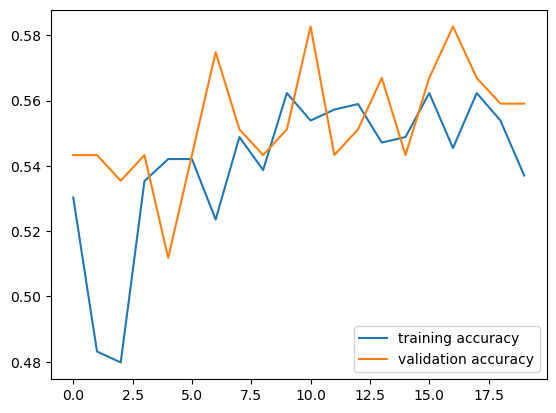

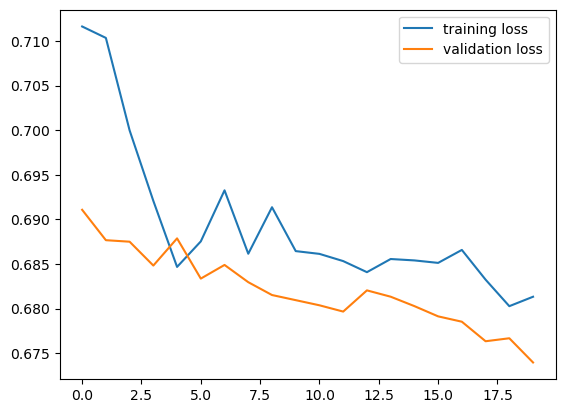

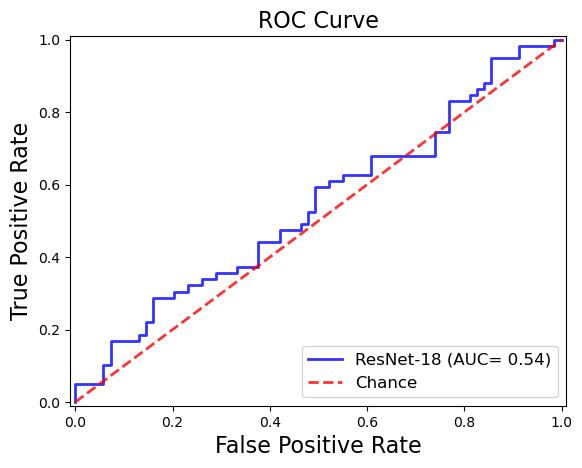

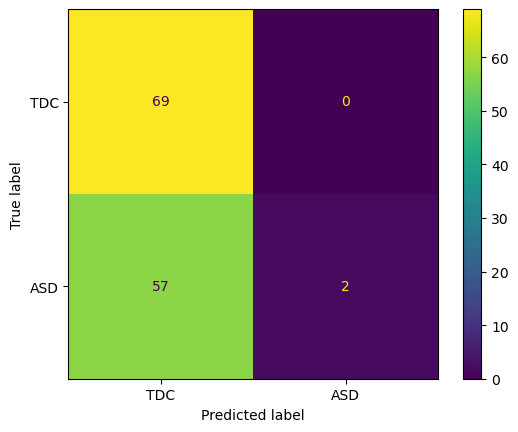

In [113]:
### Training, validation, and testing plot
plt.plot(history_model_cnn.history["accuracy"], label="training accuracy")
plt.plot(history_model_cnn.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_cnn.history["loss"], label="training loss")
plt.plot(history_model_cnn.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ResNet-18 (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['TDC','ASD']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_cnn)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

##### ViT

**Results**

In [114]:
y_pred_vit = model_vit.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin_vit = np.argmax(y_pred_vit, axis=1)
y_pred_prob_vit = y_pred_vit[:,1]
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_prob_vit)
roc_auc = auc(fpr, tpr)

tn, fp, fn, tp = confusion_matrix(y_test_bin_y_axis, y_pred_bin_vit).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Standard ViT):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

results_summary.append({
    'Model': 'ViT',
    'Accuracy': (tp+tn)/len(y_test_bin_y_axis),
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'Precision': precision,
    'F1': 2*(precision*sensitivity)/(precision+sensitivity),
    'AUC': roc_auc
})


4/4 [==============================] - 2s 290ms/step
Results for Across Y - (Standard ViT):
tp: 34
tn: 46
fp: 23
fn: 25
Accuracy:  0.625
Sensitivity:  0.576271186440678
Specificity:  0.6666666666666666
Precision:  0.5964912280701754
F1 Score: 0.5862068965517242
AUC: 0.6101694915254238


**Plots**

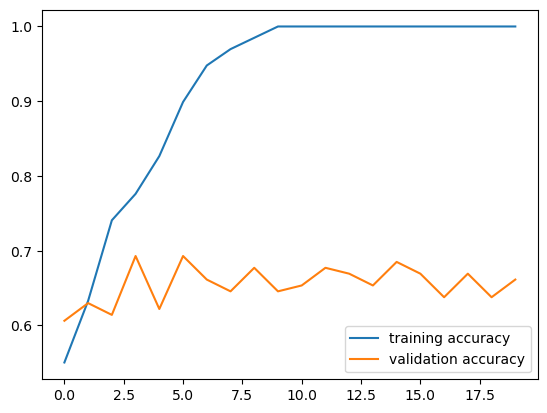

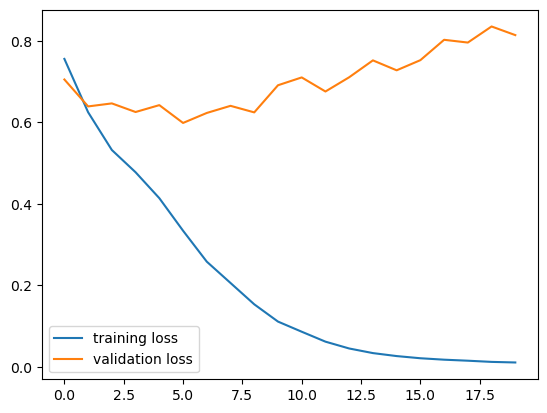

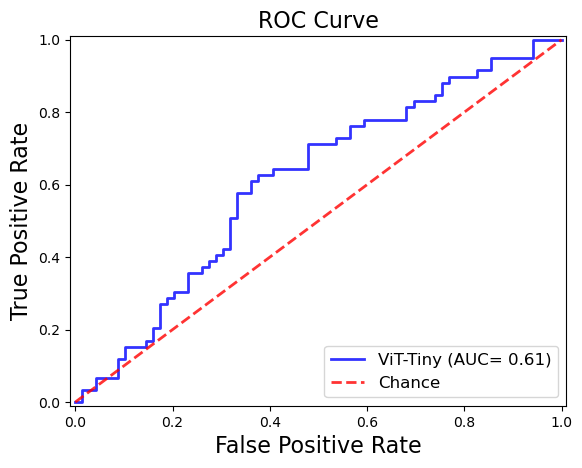

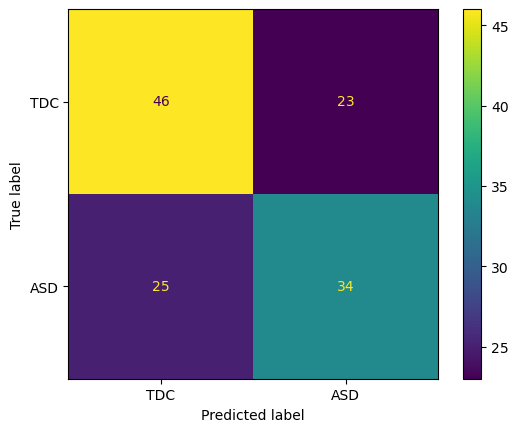

In [115]:
### Training, validation, and testing plot
plt.plot(history_model_vit.history["accuracy"], label="training accuracy")
plt.plot(history_model_vit.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_vit.history["loss"], label="training loss")
plt.plot(history_model_vit.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ViT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['TDC','ASD']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_vit)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

##### Pyramid ViT

**Results**

In [116]:
y_pred_pvt = model_pvt.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin_pvt = np.argmax(y_pred_pvt, axis=1)
y_pred_prob_pvt = y_pred_pvt[:,1]
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_prob_pvt)
roc_auc = auc(fpr, tpr)

tn, fp, fn, tp = confusion_matrix(y_test_bin_y_axis,y_pred_bin_pvt).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Pyramid ViT-Tiny):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

results_summary.append({
    'Model': 'PVT',
    'Accuracy': (tp+tn)/len(y_test_bin_y_axis),
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'Precision': precision,
    'F1': 2*(precision*sensitivity)/(precision+sensitivity),
    'AUC': roc_auc
})

4/4 [==============================] - 4s 791ms/step
Results for Across Y - (Pyramid ViT-Tiny):
tp: 31
tn: 46
fp: 23
fn: 28
Accuracy:  0.6015625
Sensitivity:  0.5254237288135594
Specificity:  0.6666666666666666
Precision:  0.5740740740740741
F1 Score: 0.5486725663716815
AUC: 0.6575779906656841


**Plots**

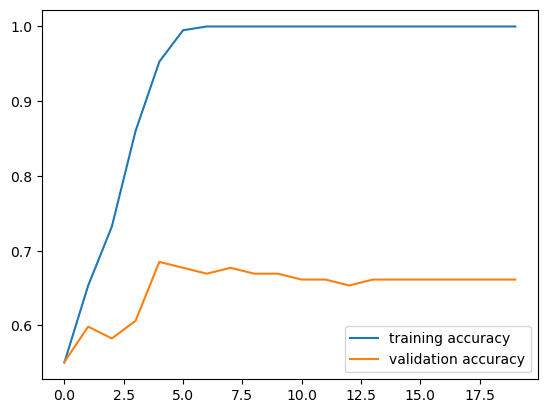

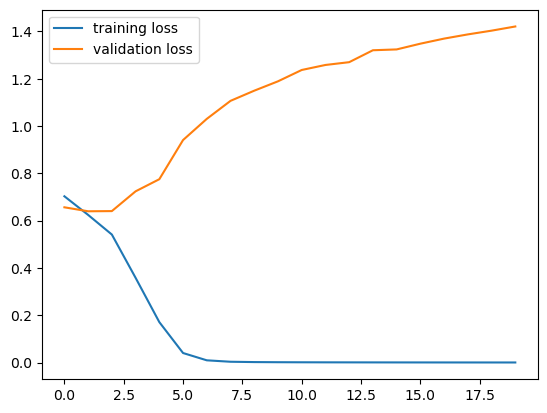

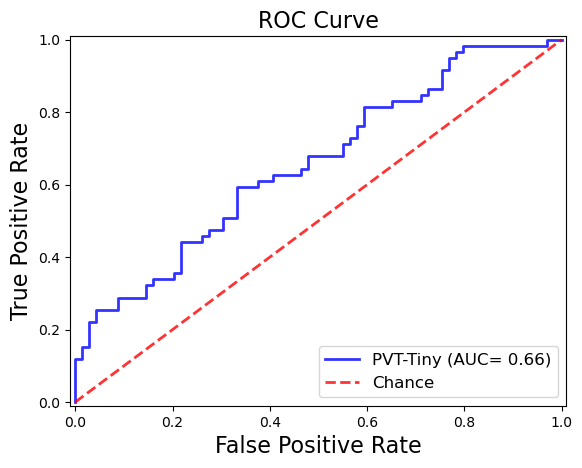

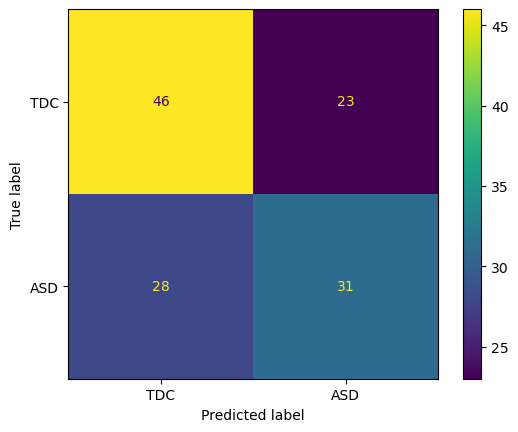

In [117]:
### Training, validation, and testing plot
plt.plot(history_model_pvt.history["accuracy"], label="training accuracy")
plt.plot(history_model_pvt.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_pvt.history["loss"], label="training loss")
plt.plot(history_model_pvt.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'PVT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['TDC','ASD']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_pvt)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

#### GNN model results

##### GCN

In [ ]:
model_gcn.eval()

y_pred_bin_gcn = []
y_pred_prob_gcn = []
y_test_bin_y_axis = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model_gcn(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
        probs = torch.softmax(out, dim=1)[:, 1]
        preds = out.argmax(dim=1)
        y_pred_bin_gcn.append(preds.cpu())
        y_pred_prob_gcn.append(probs.cpu())
        y_test_bin_y_axis.append(batch.y.cpu())

y_pred_bin_gcn = torch.cat(y_pred_bin_gcn).numpy()
y_pred_prob_gcn = torch.cat(y_pred_prob_gcn).numpy()
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_prob_gcn)
roc_auc = auc(fpr, tpr)

tn,fp,fn,tp = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gcn).flatten()

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GCN):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

results_summary.append({
    'Model': 'GCN',
    'Accuracy': (tp+tn)/len(y_test_bin_y_axis),
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'Precision': precision,
    'F1': 2*(precision*sensitivity)/(precision+sensitivity),
    'AUC': roc_auc
})

Results for Across Y - (GCN):
tp: 32
tn: 50
fp: 19
fn: 27
Accuracy:  0.640625
Sensitivity:  0.5423728813559322
Specificity:  0.7246376811594203
Precision:  0.6274509803921569
F1 Score: 0.5818181818181818
AUC: 0.6335052812576762


In [119]:
# K-Fold CV for GCN

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

fold_results = []

for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(X_gnn, y)):
    print(f"\n--- Fold {fold_idx+1}/{k_folds} ---")

    # Split this fold's train_val portion further into train/val for early stopping
    X_tv, y_tv = X_gnn[train_val_idx], y[train_val_idx]
    sex_tv, age_tv, fd_tv, site_tv = sex_bin[train_val_idx], age_raw[train_val_idx], fd_raw[train_val_idx], site_onehot[train_val_idx]
    X_te, y_te = X_gnn[test_idx], y[test_idx]
    sex_te, age_te, fd_te, site_te = sex_bin[test_idx], age_raw[test_idx], fd_raw[test_idx], site_onehot[test_idx]

    X_tr, X_va, y_tr, y_va, sex_tr, sex_va, age_tr, age_va, fd_tr, fd_va, site_tr, site_va= train_test_split(X_tv, y_tv, sex_tv, age_tv, fd_tv, site_tv, test_size=0.15, stratify=y_tv, random_state=random_state)

    age_m, age_s = age_tr.mean(), age_tr.std()
    fd_m, fd_s = fd_tr.mean(), fd_tr.std()
    z_age = lambda a: (a - age_m) / age_s
    z_fd  = lambda f: (f - fd_m) / fd_s

    fold_train_dataset = [matrix_to_data(X_tr[i], y_tr[i], sex_tr[i], z_age(age_tr[i]), z_fd(fd_tr[i]), site_tr[i]) for i in range(len(X_tr))]
    fold_val_dataset   = [matrix_to_data(X_va[i], y_va[i], sex_va[i], z_age(age_va[i]), z_fd(fd_va[i]), site_va[i]) for i in range(len(X_va))]
    fold_test_dataset  = [matrix_to_data(X_te[i], y_te[i], sex_te[i], z_age(age_te[i]), z_fd(fd_te[i]), site_te[i]) for i in range(len(X_te))]

    fold_train_loader = DataLoader(fold_train_dataset, batch_size=gnn_batch_size, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_dataset,   batch_size=gnn_batch_size, shuffle=False)
    fold_test_loader  = DataLoader(fold_test_dataset,  batch_size=gnn_batch_size, shuffle=False)

    # Fresh model per fold
    torch.manual_seed(random_state)
    model = GCN(num_node_features=num_node_features, hidden_channels=32, dropout=0.5, num_covariates=3+num_sites).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    patience = 10
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        model.train()
        for batch in fold_train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(fold_val_loader, model)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_model_state)

    # Evaluate this fold's held-out test portion
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in fold_test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    fold_acc = (preds == trues).mean()
    fold_auc = auc(*roc_curve(trues, preds)[:2])

    print(f"Fold {fold_idx+1}: acc={fold_acc:.4f}, auc={fold_auc:.4f}")
    fold_results.append({'fold': fold_idx+1, 'accuracy': fold_acc, 'auc': fold_auc})

import numpy as np
accs = [r['accuracy'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]
print(f"\nMean accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


--- Fold 1/5 ---
Fold 1: acc=0.5765, auc=0.5727

--- Fold 2/5 ---
Fold 2: acc=0.6529, auc=0.6413

--- Fold 3/5 ---
Fold 3: acc=0.6412, auc=0.6373

--- Fold 4/5 ---
Fold 4: acc=0.6765, auc=0.6679

--- Fold 5/5 ---
Fold 5: acc=0.6213, auc=0.6126

Mean accuracy: 0.6337 ± 0.0337
Mean AUC: 0.6264 ± 0.0321


##### GAT

In [ ]:
model_gat.eval()

y_pred_bin_gat = []
y_pred_prob_gat = []
y_test_bin_y_axis = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model_gat(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
        probs = torch.softmax(out, dim=1)[:, 1]
        preds = out.argmax(dim=1)
        y_pred_bin_gat.append(preds.cpu())
        y_pred_prob_gat.append(probs.cpu())
        y_test_bin_y_axis.append(batch.y.cpu())

y_pred_bin_gat = torch.cat(y_pred_bin_gat).numpy()
y_pred_prob_gat = torch.cat(y_pred_prob_gcn).numpy()
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_prob_gat)
roc_auc = auc(fpr, tpr)

tn,fp,fn,tp = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gat).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GAT):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

results_summary.append({
    'Model': 'GAT',
    'Accuracy': (tp+tn)/len(y_test_bin_y_axis),
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'Precision': precision,
    'F1': 2*(precision*sensitivity)/(precision+sensitivity),
    'AUC': roc_auc
})

Results for Across Y - (GAT):
tp: 32
tn: 50
fp: 19
fn: 27
Accuracy:  0.640625
Sensitivity:  0.5423728813559322
Specificity:  0.7246376811594203
Precision:  0.6274509803921569
F1 Score: 0.5818181818181818
AUC: 0.6335052812576762


In [ ]:
from sklearn.model_selection import StratifiedKFold
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

fold_results = []

for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(X_gnn, y)):
    print(f"\n--- Fold {fold_idx+1}/{k_folds} ---")

    # Split this fold's train_val into train/val for early stopping
    X_tv, y_tv = X_gnn[train_val_idx], y[train_val_idx]
    sex_tv, age_tv, fd_tv, site_tv = sex_bin[train_val_idx], age_raw[train_val_idx], fd_raw[train_val_idx], site_onehot[train_val_idx]
    X_te, y_te = X_gnn[test_idx], y[test_idx]
    sex_te, age_te, fd_te, site_te = sex_bin[test_idx], age_raw[test_idx], fd_raw[test_idx], site_onehot[test_idx]

    X_tr, X_va, y_tr, y_va, sex_tr, sex_va, age_tr, age_va, fd_tr, fd_va, site_tr, site_va= train_test_split(X_tv, y_tv, sex_tv, age_tv, fd_tv, site_tv, test_size=0.15, stratify=y_tv, random_state=random_state)

    age_m, age_s = age_tr.mean(), age_tr.std()
    fd_m, fd_s = fd_tr.mean(), fd_tr.std()
    z_age = lambda a: (a - age_m) / age_s
    z_fd  = lambda f: (f - fd_m) / fd_s

    fold_train_dataset = [matrix_to_data(X_tr[i], y_tr[i], sex_tr[i], z_age(age_tr[i]), z_fd(fd_tr[i]), site_tr[i]) for i in range(len(X_tr))]
    fold_val_dataset   = [matrix_to_data(X_va[i], y_va[i], sex_va[i], z_age(age_va[i]), z_fd(fd_va[i]), site_va[i]) for i in range(len(X_va))]
    fold_test_dataset  = [matrix_to_data(X_te[i], y_te[i], sex_te[i], z_age(age_te[i]), z_fd(fd_te[i]), site_te[i]) for i in range(len(X_te))]


    fold_train_loader = DataLoader(fold_train_dataset, batch_size=gnn_batch_size, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_dataset,   batch_size=gnn_batch_size, shuffle=False)
    fold_test_loader  = DataLoader(fold_test_dataset,  batch_size=gnn_batch_size, shuffle=False)

    # Fresh model per fold
    torch.manual_seed(random_state + fold_idx)
    model = GAT(num_node_features=num_node_features, hidden_channels=32, dropout=0.5, heads=heads, num_covariates=3+num_sites).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    patience = 10
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        model.train()
        for batch in fold_train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(fold_val_loader, model)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_model_state)

    # Evaluate this fold's held-out test portion
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in fold_test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    fold_acc = (preds == trues).mean()
    fold_auc = auc(*roc_curve(trues, preds)[:2])

    print(f"Fold {fold_idx+1}: acc={fold_acc:.4f}, auc={fold_auc:.4f}")
    fold_results.append({'fold': fold_idx+1, 'accuracy': fold_acc, 'auc': fold_auc})

import numpy as np
accs = [r['accuracy'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]
print(f"\nMean accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


--- Fold 1/5 ---
Fold 1: acc=0.5471, auc=0.5419

--- Fold 2/5 ---
Fold 2: acc=0.6059, auc=0.6066

--- Fold 3/5 ---
Fold 3: acc=0.6765, auc=0.6728

--- Fold 4/5 ---
Fold 4: acc=0.6882, auc=0.6837

--- Fold 5/5 ---
Fold 5: acc=0.5917, auc=0.6035

Mean accuracy: 0.6219 ± 0.0532
Mean AUC: 0.6217 ± 0.0517


In [122]:
torch.save(model_gat.state_dict(), 'gat_with_covariates2.pt')

# Ensembling

### GCN

In [123]:
def train_one_model(seed, hidden_channels=32, dropout=0.5, weight_decay=weight_decay, heads=heads, patience=10):
    torch.manual_seed(seed)
    ensemble_model = GCN(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout, num_covariates=3+num_sites).to(device) # Add heads=heads if using GCN
    optimizer = torch.optim.Adam(ensemble_model.parameters(), lr=0.001, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        ensemble_model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = ensemble_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(val_loader, ensemble_model)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = ensemble_model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    ensemble_model.load_state_dict(best_model_state)
    return ensemble_model

In [124]:
ensemble_seeds = [20, 201, 8, 12, 126, 508, 72, 100, 93, 23]

ensemble_models = []
for seed in ensemble_seeds:
    print(f"Training model with seed {seed}...")
    m = train_one_model(seed)
    ensemble_models.append(m)
print("Done training ensemble.")

Training model with seed 20...
Training model with seed 201...
Training model with seed 8...
Training model with seed 12...
Training model with seed 126...
Training model with seed 508...
Training model with seed 72...
Training model with seed 100...
Training model with seed 93...
Training model with seed 23...
Done training ensemble.


In [125]:
for i, m in enumerate(ensemble_models):
    m.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = m(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    acc = (preds == trues).mean()
    unique, counts = np.unique(preds, return_counts=True)
    print(f"Model {i} (seed {ensemble_seeds[i]}): acc={acc:.4f}, prediction distribution={dict(zip(unique, counts))}")

Model 0 (seed 20): acc=0.6641, prediction distribution={0: 84, 1: 44}
Model 1 (seed 201): acc=0.6484, prediction distribution={0: 78, 1: 50}
Model 2 (seed 8): acc=0.6875, prediction distribution={0: 65, 1: 63}
Model 3 (seed 12): acc=0.6484, prediction distribution={0: 46, 1: 82}
Model 4 (seed 126): acc=0.6484, prediction distribution={0: 72, 1: 56}
Model 5 (seed 508): acc=0.6328, prediction distribution={0: 58, 1: 70}
Model 6 (seed 72): acc=0.6953, prediction distribution={0: 68, 1: 60}
Model 7 (seed 100): acc=0.6641, prediction distribution={0: 84, 1: 44}
Model 8 (seed 93): acc=0.6562, prediction distribution={0: 77, 1: 51}
Model 9 (seed 23): acc=0.6562, prediction distribution={0: 77, 1: 51}


In [126]:
all_probs = []  # stores each model's predicted probability of class 1

for m in ensemble_models:
    m.eval()
    probs = []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = m(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            prob = torch.softmax(out, dim=1)[:, 1]  # probability of class 1 (ASD)
            probs.append(prob.cpu())
    all_probs.append(torch.cat(probs).numpy())

# Get true labels
y_test_bin_y_axis = []
with torch.no_grad():
    for batch in test_loader:
        y_test_bin_y_axis.append(batch.y.cpu())
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

# Average probabilities across ensemble members, then threshold at 0.5
avg_probs = np.mean(all_probs, axis=0)
y_pred_bin_ensemble = (avg_probs >= 0.5).astype(int)

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, avg_probs)
roc_auc = auc(fpr, tpr)

tn, fp, fn, tp = confusion_matrix(y_test_bin_y_axis, y_pred_bin_ensemble).flatten()

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GCN Ensemble):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

Results for Across Y - (GCN Ensemble):
tp: 37
tn: 51
fp: 18
fn: 22
Accuracy:  0.6875
Sensitivity:  0.6271186440677966
Specificity:  0.7391304347826086
Precision:  0.6727272727272727
F1 Score: 0.6491228070175439
AUC: 0.7435519528371408


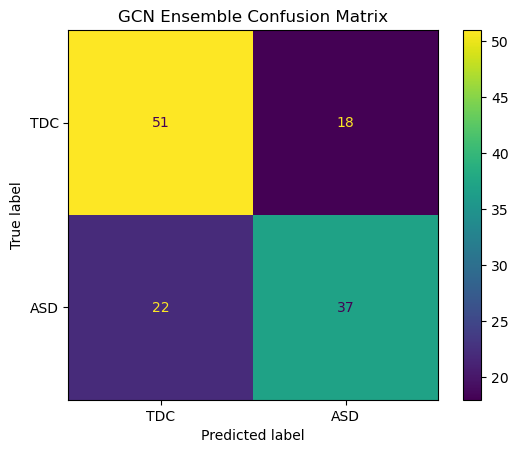

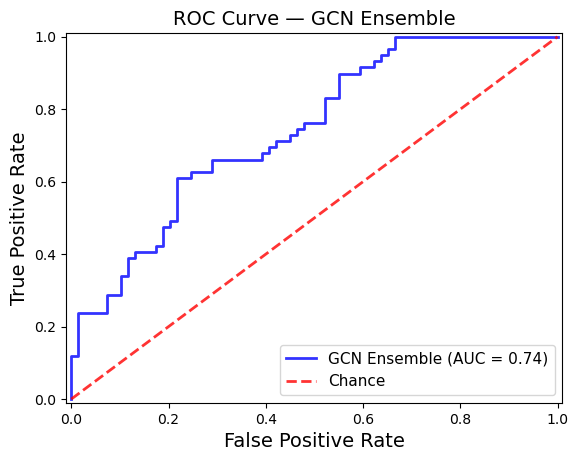

In [127]:

# Confusion matrix plot
cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['TDC', 'ASD'])
disp.plot()
plt.title('GCN Ensemble Confusion Matrix')
plt.show()

# ROC curve plot
plt.plot(fpr, tpr, lw=2, color='b', label=f'GCN Ensemble (AUC = {roc_auc:.2f})', alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve — GCN Ensemble', fontsize=14)
plt.legend(loc="lower right", prop={'size': 11})
plt.show()

### GAT

In [128]:
def train_one_model(seed, hidden_channels=32, dropout=0.5, weight_decay=weight_decay, heads=heads, patience=10):
    torch.manual_seed(seed)
    ensemble_model = GAT(num_node_features=num_node_features, hidden_channels=hidden_channels, heads=heads, dropout=dropout, num_covariates=3+num_sites).to(device) # Add heads=heads if using GCN
    optimizer = torch.optim.Adam(ensemble_model.parameters(), lr=0.001, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        ensemble_model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = ensemble_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(val_loader, ensemble_model)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = ensemble_model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    ensemble_model.load_state_dict(best_model_state)
    return ensemble_model

In [129]:
n_ensemble = 10
ensemble_seeds = [20, 201, 8, 12, 126, 508, 72, 100, 93, 23]  # Example seeds for reproducibility

gat_ensemble_models = []
for seed in ensemble_seeds:
    print(f"Training model with seed {seed}...")
    m = train_one_model(seed)
    gat_ensemble_models.append(m)
print("Done training ensemble.")

Training model with seed 20...
Training model with seed 201...
Training model with seed 8...
Training model with seed 12...
Training model with seed 126...
Training model with seed 508...
Training model with seed 72...
Training model with seed 100...
Training model with seed 93...
Training model with seed 23...
Done training ensemble.


In [130]:
for i, m in enumerate(gat_ensemble_models):
    m.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = m(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    acc = (preds == trues).mean()
    unique, counts = np.unique(preds, return_counts=True)
    print(f"Model {i} (seed {ensemble_seeds[i]}): acc={acc:.4f}, prediction distribution={dict(zip(unique, counts))}")

Model 0 (seed 20): acc=0.6562, prediction distribution={0: 75, 1: 53}
Model 1 (seed 201): acc=0.6641, prediction distribution={0: 68, 1: 60}
Model 2 (seed 8): acc=0.6641, prediction distribution={0: 88, 1: 40}
Model 3 (seed 12): acc=0.6250, prediction distribution={0: 65, 1: 63}
Model 4 (seed 126): acc=0.6328, prediction distribution={0: 50, 1: 78}
Model 5 (seed 508): acc=0.6797, prediction distribution={0: 52, 1: 76}
Model 6 (seed 72): acc=0.6953, prediction distribution={0: 44, 1: 84}
Model 7 (seed 100): acc=0.6641, prediction distribution={0: 72, 1: 56}
Model 8 (seed 93): acc=0.6719, prediction distribution={0: 55, 1: 73}
Model 9 (seed 23): acc=0.6875, prediction distribution={0: 61, 1: 67}


In [131]:
all_probs = []  # stores each model's predicted probability of class 1

for m in gat_ensemble_models:
    m.eval()
    probs = []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = m(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            prob = torch.softmax(out, dim=1)[:, 1]  # probability of class 1 (ASD)
            probs.append(prob.cpu())
    all_probs.append(torch.cat(probs).numpy())

# Get true labels
y_test_bin_y_axis = []
with torch.no_grad():
    for batch in test_loader:
        y_test_bin_y_axis.append(batch.y.cpu())
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

# Average probabilities across ensemble members, then threshold at 0.5
avg_probs = np.mean(all_probs, axis=0)
y_pred_bin_ensemble = (avg_probs >= 0.5).astype(int)

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, avg_probs)

gat_roc_auc = auc(fpr, tpr)

tn, fp, fn, tp = confusion_matrix(y_test_bin_y_axis, y_pred_bin_ensemble).flatten()

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GAT Ensemble):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', gat_roc_auc)

Results for Across Y - (GAT Ensemble):
tp: 42
tn: 44
fp: 25
fn: 17
Accuracy:  0.671875
Sensitivity:  0.711864406779661
Specificity:  0.6376811594202898
Precision:  0.6268656716417911
F1 Score: 0.6666666666666667
AUC: 0.7654139032178826


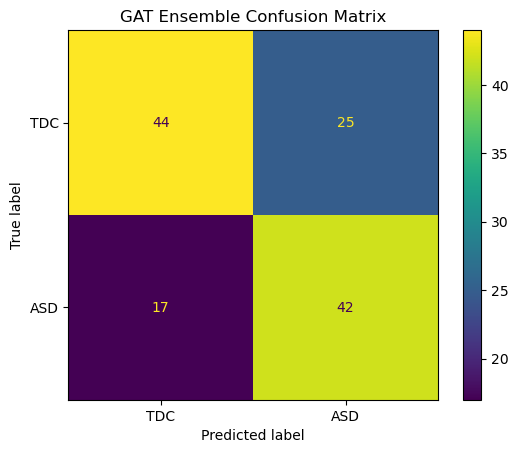

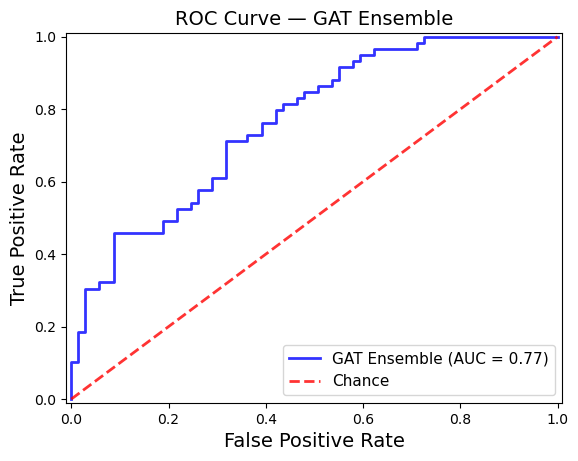

In [132]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix plot
cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['TDC', 'ASD'])
disp.plot()
plt.title('GAT Ensemble Confusion Matrix')
plt.show()

# ROC curve plot
plt.plot(fpr, tpr, lw=2, color='b', label=f'GAT Ensemble (AUC = {gat_roc_auc:.2f})', alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve — GAT Ensemble', fontsize=14)
plt.legend(loc="lower right", prop={'size': 11})
plt.show()

## Plot Exports

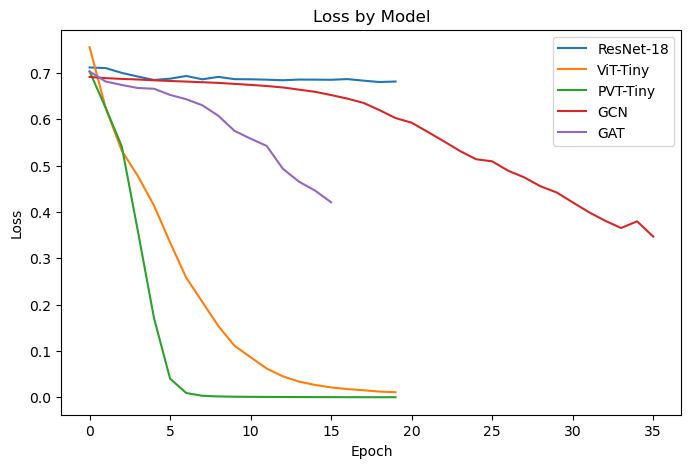

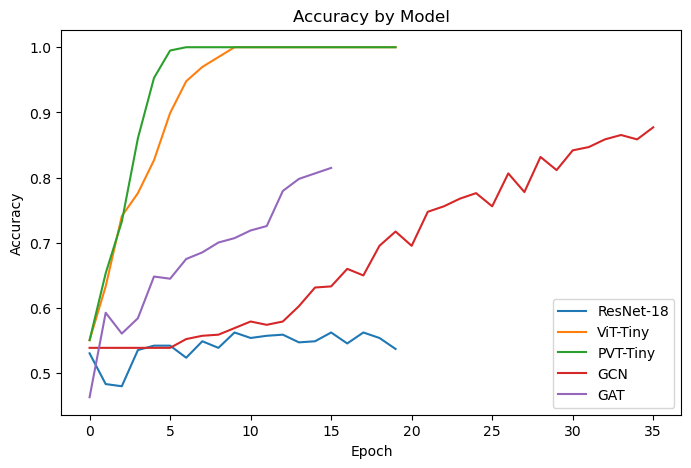

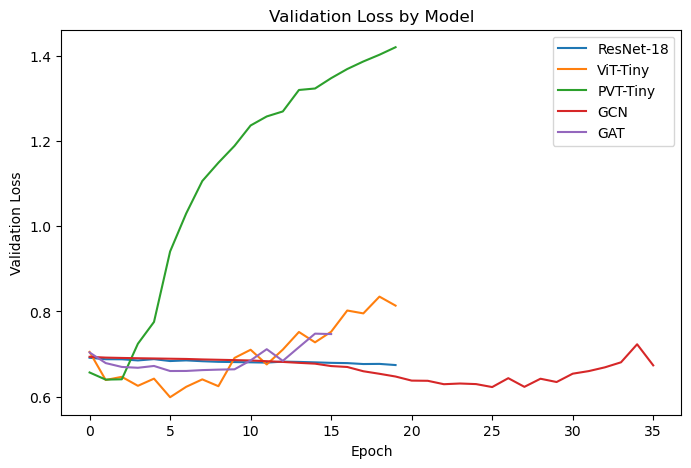

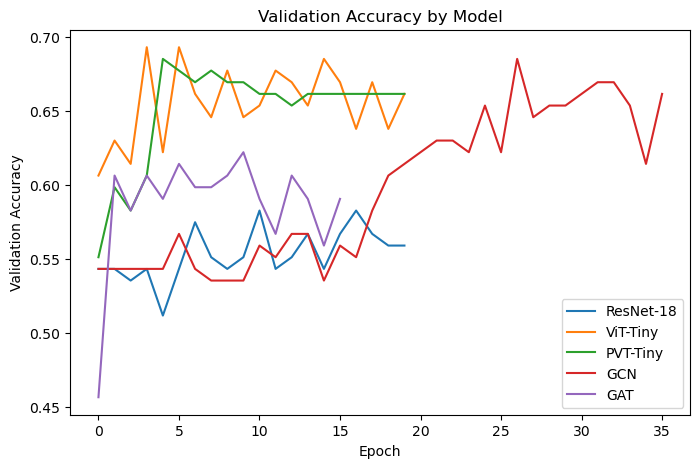

In [133]:
import matplotlib.pyplot as plt

histories = {
    'ResNet-18':   history_model_cnn.history,
    'ViT-Tiny':    history_model_vit.history,
    'PVT-Tiny':    history_model_pvt.history,
    'GCN':         history_model_gnn,   # plain dict, not a keras History object
    'GAT':         history_model_gat,   # plain dict, not a keras History object
}

plt.figure(figsize=(8, 5))
for name, h in histories.items():
    plt.plot(h['loss'], label=name) # loss, accuracy, val_loss, val_accuracy
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss by Model')
plt.legend()
plt.savefig(f'loss_by_model.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
for name, h in histories.items():
    plt.plot(h['accuracy'], label=name) # loss, accuracy, val_loss, val_accuracy
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy by Model')
plt.legend()
plt.savefig(f'accuracy_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
for name, h in histories.items():
    plt.plot(h['val_loss'], label=name) # loss, accuracy, val_loss, val_accuracy
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss by Model')
plt.legend()
plt.savefig(f'val_loss_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
for name, h in histories.items():
    plt.plot(h['val_accuracy'], label=name) # loss, accuracy, val_loss, val_accuracy
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy by Model')
plt.legend()
plt.savefig(f'val_accuracy_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

In [134]:
results_summary
results_df = pd.DataFrame(results_summary).set_index('Model')
results_df = results_df.round(3)
display(results_df)   # or print(results_df) if display() isn't available

results_df.to_csv('model_comparison_summary.csv')

,Accuracy,Sensitivity,Specificity,Precision,F1,AUC
Model,,,,,,
CNN,0.555,0.034,1.000,1.000,0.066,0.543
ViT,0.625,0.576,0.667,0.596,0.586,0.610
PVT,0.602,0.525,0.667,0.574,0.549,0.658
GCN,0.641,0.542,0.725,0.627,0.582,0.634
GAT,0.641,0.542,0.725,0.627,0.582,0.634
